<img src="http://meusite.mackenzie.br/rogerio/mackenzie_logo/UPM.2_horizontal_vermelho.jpg"  width=300, align="right">
<br>
<br>
<br>
<br>
<br>

# **Algoritmos Genéticos**
---


In [54]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em orgem alfabética (*informe \<RA\>,\<nome\>*)
Aluno1 = '10418358, Bruna Aguiar Muchiuti  ' #@param {type:"string"}
Aluno2 = '10418247, Gabriel Ken Kazama Geronazzo' #@param {type:"string"}
Aluno3 = '10418013, Lucas Pires de Camargo Sarai' #@param {type:"string"}
Aluno4 = '10410798, Jessica dos Santos Santana Bispo ' #@param {type:"string"}
Aluno5 = '10409053, Otávio Augusto Freire de Andrade Bruzadin ' #@param {type:"string"}
Aluno6 = 'none' #@param {type:"string"}

In [55]:
#@title **Escolha a opção de Exercício Selecionado**
Exercicio_selecionado = "Exercício B. Forca" #@param ["Exercício A. Otimização multi-objetivo", "Exercício B. Forca", "Exercício C. Sudoku"]




# **Resumo**

Neste trabalho foi desenvolvida uma implementação com PyGDA de um algoritmo genético para resolver o jogo FORCA.

# **Descrição da Solução**

A implementação pode ser explicada dentro de 5 tópicos principais:

* **Definição da representação das soluções em genes e próxima geração:** Cada gene é uma combinação de letras que pode ou não ser a solução final. E para a seleção da próxima geração, foi definida a seleção dos 6 genes com maior pontuação resultante da função de fitness.
* **Função de fitness:** Para cada letra na posição correta a pontuação aumenta em 20, enquanto para cada erro a pontuação reduz em 2. E para gerar soluções mais diversas e evitar soluções com muitas letras repetidas, uma penalidade de -1 ponto é aplicada para cada caractere repetido.
* ***Crossover*:** Para realizar o *Crossover* foi aplicado o método '*single_point*', onde é feita uma separação única nos dois genes a serem combinados e a solução é resultado da concatenação de uma parte de cada um deles, enquanto a outra é descartada.
* **Mutação:** Foi aplicada uma mutação de forma aleatória, onde 25% dos genes das soluções podem ser substituídos por novos genes de fora.
* **Critério de Parada:** Ou chegar na palavra-alvo ou não achar a palavra-alvo dentro de 120 gerações.

# **Implementação**


In [56]:
!pip install pygad -q

import random
import string
import numpy as np
import pygad

In [57]:
alphabet = list(string.ascii_uppercase)
char_to_idx = {c: i for i, c in enumerate(alphabet)}
idx_to_char = {i: c for i, c in enumerate(alphabet)}

def run_test(secret_word: str):
    print("\n==============================")
    print("Testando palavra:", secret_word)
    print("==============================")

    word_size = len(secret_word)
    target = np.array([char_to_idx[c] for c in secret_word], dtype=int)

    def decode(solution):
        return "".join(idx_to_char[int(g)] for g in solution)

    def fitness_func(ga_instance, solution, solution_idx):
        solution = np.array(solution, dtype=int)
        hits = np.sum(solution == target)
        wrong_positions = np.sum(solution != target)

        unique_bonus = len(set(solution.tolist()))
        repeated_penalty = len(solution) - unique_bonus

        score = (hits * 20) - (wrong_positions * 2) - repeated_penalty
        return score

    def on_generation(ga_instance):
        best_solution, best_fitness, _ = ga_instance.best_solution()
        guess = decode(best_solution)
        print(f"Geração {ga_instance.generations_completed:03d} | {guess} | Fitness: {best_fitness}")

    num_generations = 120

    unique_target_chars = len(set(list(secret_word)))
    repeated_penalty = len(secret_word) - unique_target_chars
    target_fitness = len(secret_word) * 20 - repeated_penalty

    ga_instance = pygad.GA(
        num_generations=num_generations,
        num_parents_mating=6,
        fitness_func=fitness_func,
        sol_per_pop=30,
        num_genes=word_size,
        gene_space=list(range(len(alphabet))),
        parent_selection_type="sss",
        keep_parents=2,
        crossover_type="single_point",
        mutation_type="random",
        mutation_percent_genes=25,
        on_generation=on_generation,
        stop_criteria=[f"reach_{target_fitness}"]
    )

    ga_instance.run()

    best_solution, best_fitness, _ = ga_instance.best_solution()
    best_word = decode(best_solution)

    print("\nResultado final")
    print("Palavra secreta:", secret_word)
    print("Melhor solução :", best_word)
    print("Fitness alvo:", target_fitness)
    print("Fitness final:", best_fitness)

    if best_word == secret_word:
        print("Solução encontrada!")
    else:
        print(f"Não encontrou a solução dentro do limite de {num_generations} gerações")

    ga_instance.plot_fitness()

# **Resultados (Testes)**


**Objetivo:** Testar com uma palavra curta de 4 letras e com letras repetidas


Testando palavra: JAVA
Geração 001 | GAVA | Fitness: 57
Geração 002 | GAVA | Fitness: 57
Geração 003 | JAVA | Fitness: 79

Resultado final
Palavra secreta: JAVA
Melhor solução : JAVA
Fitness alvo: 79
Fitness final: 79
Solução encontrada!


/usr/local/lib/python3.12/dist-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


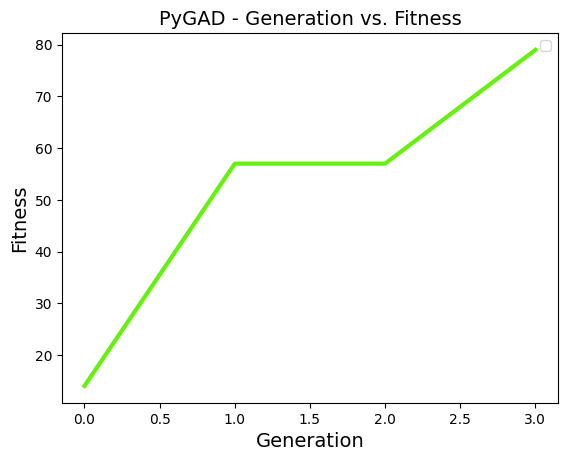

In [58]:
run_test("JAVA")

**Resultado:** A repetição de letras e o tamanho reduzido auxiliaram a encontrar a solução em pouco tempo.

**Objetivo:** testar uma palavra curta, com letras diferentes.


Testando palavra: RUBY
Geração 001 | FMBR | Fitness: 14
Geração 002 | TJBW | Fitness: 14
Geração 003 | PJBS | Fitness: 14
Geração 004 | PRBC | Fitness: 14
Geração 005 | ZLBS | Fitness: 14
Geração 006 | PTBQ | Fitness: 14
Geração 007 | RTBQ | Fitness: 36
Geração 008 | RTBD | Fitness: 36
Geração 009 | RNBK | Fitness: 36
Geração 010 | RFBY | Fitness: 58
Geração 011 | RFBY | Fitness: 58
Geração 012 | RWBY | Fitness: 58
Geração 013 | RGBY | Fitness: 58
Geração 014 | RVBY | Fitness: 58
Geração 015 | RWBY | Fitness: 58
Geração 016 | RUBY | Fitness: 80

Resultado final
Palavra secreta: RUBY
Melhor solução : RUBY
Fitness alvo: 80
Fitness final: 80
Solução encontrada!


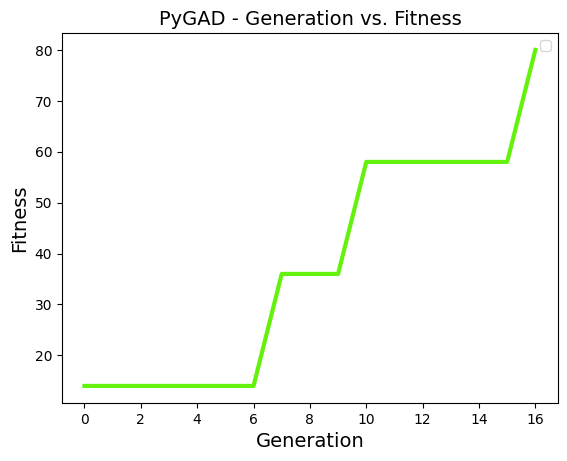

In [59]:
run_test("RUBY")

**Resultado:** Por ter letras mais variadas, precisou de mais gerações para encontrar a solução.

**Objetivo:** Testar outra palavra um pouco maior de 6 letras com letras diferentes.


Testando palavra: KOTLIN
Geração 001 | KECRDN | Fitness: 32
Geração 002 | KEGLDN | Fitness: 54
Geração 003 | KEGLDN | Fitness: 54
Geração 004 | KOJLDN | Fitness: 76
Geração 005 | KOJLDN | Fitness: 76
Geração 006 | KOJLEN | Fitness: 76
Geração 007 | KOYLDN | Fitness: 76
Geração 008 | KOTLYN | Fitness: 98
Geração 009 | KOTLYN | Fitness: 98
Geração 010 | KOTLYN | Fitness: 98
Geração 011 | KOTLYN | Fitness: 98
Geração 012 | KOTLIN | Fitness: 120

Resultado final
Palavra secreta: KOTLIN
Melhor solução : KOTLIN
Fitness alvo: 120
Fitness final: 120
Solução encontrada!


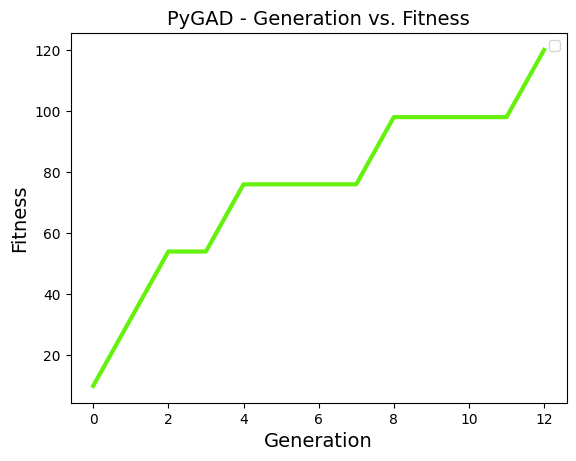

In [60]:
run_test("KOTLIN")

**Resultado:** Aumentando apenas um pouco o tamanho, mesmo com letras variadas, precisou de menos gerações que se comparado com 4 palavras. Isso pode ser resultante pelos processos probabilísticos e não determinísticos de geração de novas gerações, pois por mais que a tendência fosse levar mais gerações, pode ocorrer de precisar de menos gerações.

**Objetivo:** Testar uma palavra de 6 letras e várias letras repetidas.


Testando palavra: BANANA
Geração 001 | BAMZRA | Fitness: 53
Geração 002 | BAMZRA | Fitness: 53
Geração 003 | BANKGA | Fitness: 75
Geração 004 | BANKGA | Fitness: 75
Geração 005 | BANSLA | Fitness: 75
Geração 006 | BANKWA | Fitness: 75
Geração 007 | BANLSA | Fitness: 75
Geração 008 | BANRNA | Fitness: 96
Geração 009 | BANRNA | Fitness: 96
Geração 010 | BANINA | Fitness: 96
Geração 011 | BANINA | Fitness: 96
Geração 012 | BANONA | Fitness: 96
Geração 013 | BANINA | Fitness: 96
Geração 014 | BACANA | Fitness: 96
Geração 015 | BANVNA | Fitness: 96
Geração 016 | BAEANA | Fitness: 96
Geração 017 | BANWNA | Fitness: 96
Geração 018 | BANWNA | Fitness: 96
Geração 019 | BANANA | Fitness: 117

Resultado final
Palavra secreta: BANANA
Melhor solução : BANANA
Fitness alvo: 117
Fitness final: 117
Solução encontrada!


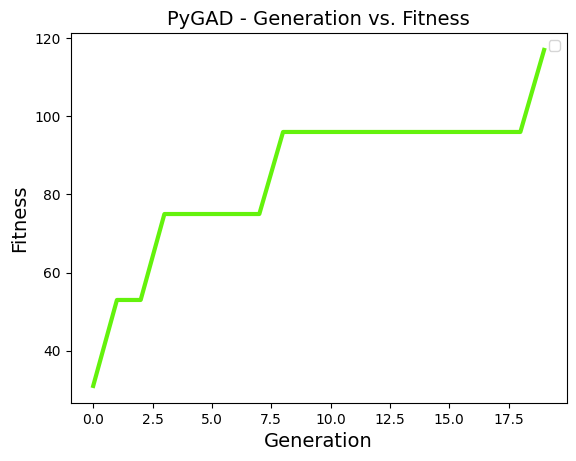

In [61]:
run_test("BANANA")

**Resultado:** No mesmo tamanho, mas repetindo mais as letras, não foi melhor em termos de número de gerações em relação ao anterior, o que pode ser explicado pelos processos probabilísticos e não determinísticos empregados.

**Objetivo:** Testar uma palavra-alvo que seja composta exclusivamente de letras repetidas, para saber se a penalidade por repetição impediria a geração da solução correta.


Testando palavra: AAAAA
Geração 001 | HAAIL | Fitness: 33
Geração 002 | HAAAT | Fitness: 54
Geração 003 | AAAAF | Fitness: 75
Geração 004 | AAAAF | Fitness: 75
Geração 005 | AAAAF | Fitness: 75
Geração 006 | AAAAH | Fitness: 75
Geração 007 | AAOAA | Fitness: 75
Geração 008 | AARAA | Fitness: 75
Geração 009 | AAFAA | Fitness: 75
Geração 010 | AAWAA | Fitness: 75
Geração 011 | AABAA | Fitness: 75
Geração 012 | AAAPA | Fitness: 75
Geração 013 | AAAAA | Fitness: 96

Resultado final
Palavra secreta: AAAAA
Melhor solução : AAAAA
Fitness alvo: 96
Fitness final: 96
Solução encontrada!


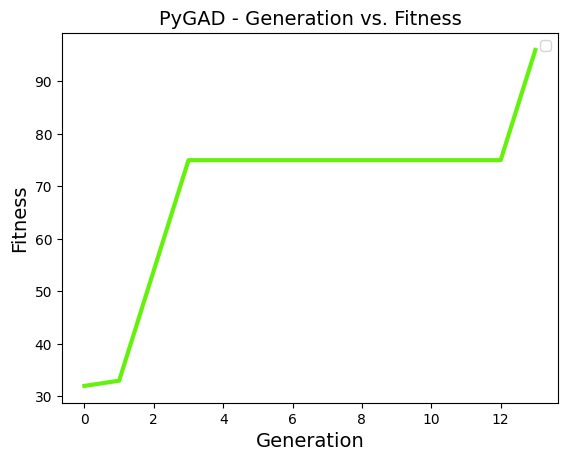

In [62]:
run_test("AAAAA")

**Resultado:** Por mais que soluções com muitas letras repetidas são penalizadas, esse teste provou que isso não impede de o algoritmo encontrar uma palavra-alvo que seja composta apenas pela mesma letra.

**Objetivo:** Testar uma palavra muito maior com 46 letras, algumas repetidas, outras variadas.


Testando palavra: PNEUMOULTRAMICROSCOPICOSSILICOVULCANOCONIOTICO
Geração 001 | ETECMVNPFNCVMUBDNRZXRTPEFNIZVSVUGQBKCAENRBVHCO | Fitness: 38
Geração 002 | LFLUMYOJSHKQOBJOGHEDGCWAEJLRCUVKTSHXUGWNEAUBKZ | Fitness: 62
Geração 003 | ETEGLSSPUOJPBBGSADDYBFZNSVOSFCVUDHAXOKLNGDQZCO | Fitness: 82
Geração 004 | LFNURYZJIHMFOBRUKZWDCCVARJLICUVKTAHXOGWNGDTBKZ | Fitness: 104
Geração 005 | UAEUMVUXFOYZYUHDHVFIRXPEUILFCUVZSAHXOGWNGMTBKZ | Fitness: 128
Geração 006 | UAEUMVUXFOYZYUHDHVFIRXPEUILFCUVZSAHXOGWNGMTBKZ | Fitness: 128
Geração 007 | USEUCPUOFOYZOBRYZZWDCCPARQLICUVKWZYXOZTNGDMSKZ | Fitness: 128
Geração 008 | USEUCPUOFOYZOBRYZZWDCCPARQLICUVKWZYXOZTNGDMSKZ | Fitness: 128
Geração 009 | USEUCPUOFOYZOBRYZZWDCCPARQLICUVKWZYXOZTNGDMSKZ | Fitness: 128
Geração 010 | USEUCPUOFOYZOBRYZZWDCCPARQLICUVKWZYXOZTNGDMSKZ | Fitness: 128
Geração 011 | USEMCYUOVLYMPCRYUZGDCZJQSQLICUVPVZYXIZMNYATSKI | Fitness: 148
Geração 012 | USEMCYUOVLYMPCRYUZGDCZJQSQLICUVPVZYXIZMNYATSKI | Fitness: 148
Geração 013 | USEMCYUOVLY

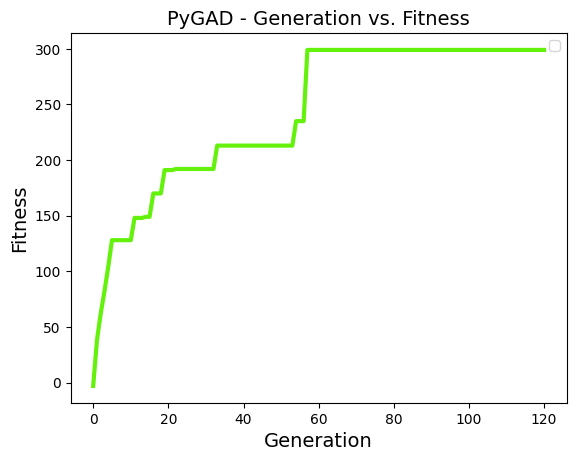

In [63]:
run_test("PNEUMOULTRAMICROSCOPICOSSILICOVULCANOCONIOTICO")

**Resultado:** Com uma palavra bem maior, no número limite de 120 gerações a solução perfeita não foi encontrada, provavelmente pela baixa probabilidade de correspondência com 46 letras.

# **Referências**

**Materiais de aula**. Disponível em: https://github.com/Rogerio-mack/IA_2026S1. Acesso em: 3 abr. 2026.

**PyGAD - Python Genetic Algorithm! — PyGAD 2.16.1 documentation**. Disponível em: <https://pygad.readthedocs.io/en/latest/>. Acesso em: 3 abr. 2026.

PYTHON SOFTWARE FOUNDATION. **Python Documentation**. [S. l.], [s.d.]. Disponível em: https://docs.python.org/3/. Acesso em: 3 abr. 2026.

---

In [64]:
#@title **Avaliação**
Resumo = 10 #@param {type:"slider", min:0, max:10, step:1}

Descricao_solucao = 7 #@param {type:"slider", min:0, max:10, step:1}

Implementacao = 9 #@param {type:"slider", min:0, max:10, step:1}

Resultados = 6 #@param {type:"slider", min:0, max:10, step:1}

Referencias = 7 #@param {type:"slider", min:0, max:10, step:1}

Geral = 7 #@param {type:"slider", min:0, max:10, step:1}








In [65]:
#@title **Nota Final**
nota = Resumo + Implementacao + Resultados + Referencias + Geral

nota = nota / 5

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_tia = []
lista_nome = []

for i in range(1,7):
  alumno_variable_name = "Aluno" + str(i)
  # Access the variable's value from the global scope
  alumno_value = globals()[alumno_variable_name]

  # Check if the value is not empty and contains a comma to ensure it's a valid entry
  if alumno_value and ',' in alumno_value:
    lista = alumno_value.split(',')
    # Ensure there are at least two elements after splitting
    if len(lista) >= 2:
      lista_tia.append(lista[0].strip())
      lista_nome.append(lista[1].strip().upper())

alunos['tia'] = lista_tia
alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 7.8



,tia,nome,nota
0,10418358,BRUNA AGUIAR MUCHIUTI,7.8
1,10418247,GABRIEL KEN KAZAMA GERONAZZO,7.8
2,10418013,LUCAS PIRES DE CAMARGO SARAI,7.8
3,10410798,JESSICA DOS SANTOS SANTANA BISPO,7.8
4,10409053,OTÁVIO AUGUSTO FREIRE DE ANDRADE BRUZADIN,7.8
